# MNIST Digit Classification
##### In this assignment, you will work with the [MNIST handwritten digits dataset](http://yann.lecun.com/exdb/mnist/) to implement and compare two supervised learning algorithms: Logistic Regression and Neural Networks. You will gain hands-on experience with data preprocessing, model training, evaluation, and visualization techniques commonly used in machine learning.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from sklearn.datasets import fetch_openml
    from sklearn.model_selection import train_test_split
    from sklearn.linear_model import LogisticRegression
    from sklearn.preprocessing import StandardScaler
    from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
    from sklearn.neural_network import MLPClassifier
    import seaborn as sns
except ImportError as e:
    import subprocess
    import sys
    
    print(f"Missing package: {str(e).split()[-1]}")
    print("Installing required packages...")
    %pip install scikit-learn
    %pip install seaborn


### Part 1: Data Loading and Exploration (4 points)
1. Load the MNIST dataset using fetch_openml
2. Print the following dataset characteristics:
   - Dataset dimensions and size
   - Number of classes
3. Visualize sample digits from the dataset


In [2]:
#Provide your code for part 1-1 here
from sklearn.datasets import fetch_openml

mnist = fetch_openml('mnist_784', version=1, as_frame=False)
X, y = mnist.data, mnist.target

In [3]:
#Provide your code for part 1-2 here
print("Dataset dimensions:", X.shape)
print("Number of samples:", X.shape[0])
print("Number of features:", X.shape[1])
print("Number of classes:", len(np.unique(y)))

Dataset dimensions: (70000, 784)
Number of samples: 70000
Number of features: 784
Number of classes: 10


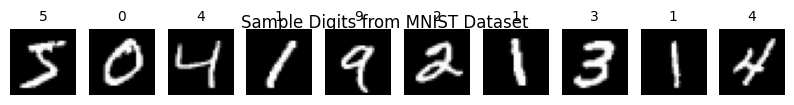

In [4]:
#Provide your code for part 1-3 here

fig, axes = plt.subplots(1, 10, figsize=(10, 1))
for i in range(10):
    axes[i].imshow(X[i].reshape(28, 28), cmap='gray')
    axes[i].axis('off')
    axes[i].set_title(y[i], fontsize=10)
plt.suptitle("Sample Digits from MNIST Dataset", fontsize=12)
plt.show()

### Part 2: Data Preprocessing (4 points)
1. Scale the pixel values to range [0,1] by dividing by 255
2. Split the data into training (80%) and testing (20%) sets
3. Create a StandardScaler object and fit it on the training data
4. Transform both training and test data using the fitted scaler
5. Print the shapes of the resulting training and test sets


In [5]:
# Provide your code for part 2 here
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Scale pixel values to [0, 1]
X_scaled = X / 255.0

# 2. Split into training (80%) and testing (20%)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# 3. Create a StandardScaler and fit on training data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

# 4. Transform test data using the same scaler
X_test_scaled = scaler.transform(X_test)

# 5. Print resulting shapes
print("X_train_scaled shape:", X_train_scaled.shape)
print("X_test_scaled shape:", X_test_scaled.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train_scaled shape: (56000, 784)
X_test_scaled shape: (14000, 784)
y_train shape: (56000,)
y_test shape: (14000,)


### Part 3: Model Training and Evaluation (8 points)
1. Train a Logistic Regression model using the training data. Use the default parameters.
2. Train a Neural Network model using the training data. The neural network should have 2 hidden layers with 100 and 50 neurons respectively. Use the Adam optimizer and a learning rate of 0.001.

In [6]:
# Provide your code for part 3-1 here
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Train logistic regression model
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train_scaled, y_train)

# Predict and evaluate
lr_preds = lr_model.predict(X_test_scaled)
lr_accuracy = accuracy_score(y_test, lr_preds)
print("Logistic Regression Accuracy:", lr_accuracy)

Logistic Regression Accuracy: 0.9154285714285715


In [7]:
# Provide your code for part 3-2 here
from sklearn.neural_network import MLPClassifier

# Train MLP with two hidden layers: 100 and 50 neurons
mlp = MLPClassifier(hidden_layer_sizes=(100, 50), solver='adam', learning_rate_init=0.001, max_iter=20, random_state=42)
mlp.fit(X_train_scaled, y_train)

# Predict and evaluate
mlp_preds = mlp.predict(X_test_scaled)
mlp_accuracy = accuracy_score(y_test, mlp_preds)
print("Neural Network Accuracy:", mlp_accuracy)

Neural Network Accuracy: 0.9711428571428572


/home/codespace/.local/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(


### Part 4: Model Comparison and Visualization (4 points)
1. Use a bar plot to compare the accuracy of both models on the test data
2. Print the classification report and confusion matrix for both models
3. Visualize the misclassified examples for both models


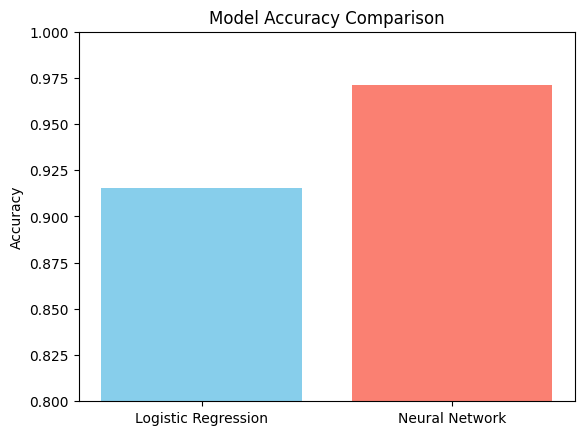

In [8]:
# Provide your code for part 4-1 here
import matplotlib.pyplot as plt

# Compare accuracies
models = ['Logistic Regression', 'Neural Network']
accuracies = [lr_accuracy, mlp_accuracy]

plt.bar(models, accuracies, color=['skyblue', 'salmon'])
plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy')
plt.ylim(0.8, 1.0)
plt.show()

In [9]:
# Provide your code for part 4-2 here
from sklearn.metrics import classification_report, confusion_matrix

print("Logistic Regression Report:")
print(classification_report(y_test, lr_preds))
print("Confusion Matrix:\n", confusion_matrix(y_test, lr_preds))

print("\nNeural Network Report:")
print(classification_report(y_test, mlp_preds))
print("Confusion Matrix:\n", confusion_matrix(y_test, mlp_preds))

Logistic Regression Report:
              precision    recall  f1-score   support

           0       0.96      0.96      0.96      1343
           1       0.94      0.97      0.96      1600
           2       0.90      0.89      0.90      1380
           3       0.90      0.89      0.89      1433
           4       0.92      0.92      0.92      1295
           5       0.88      0.88      0.88      1273
           6       0.93      0.94      0.94      1396
           7       0.92      0.94      0.93      1503
           8       0.90      0.86      0.88      1357
           9       0.89      0.90      0.90      1420

    accuracy                           0.92     14000
   macro avg       0.91      0.91      0.91     14000
weighted avg       0.92      0.92      0.92     14000

Confusion Matrix:
 [[1283    1   10    0    1   14   22    4    6    2]
 [   0 1555    6    9    3    5    1    4   14    3]
 [   5   19 1234   18   13   14   21   16   28   12]
 [   7    9   36 1272    1   41    

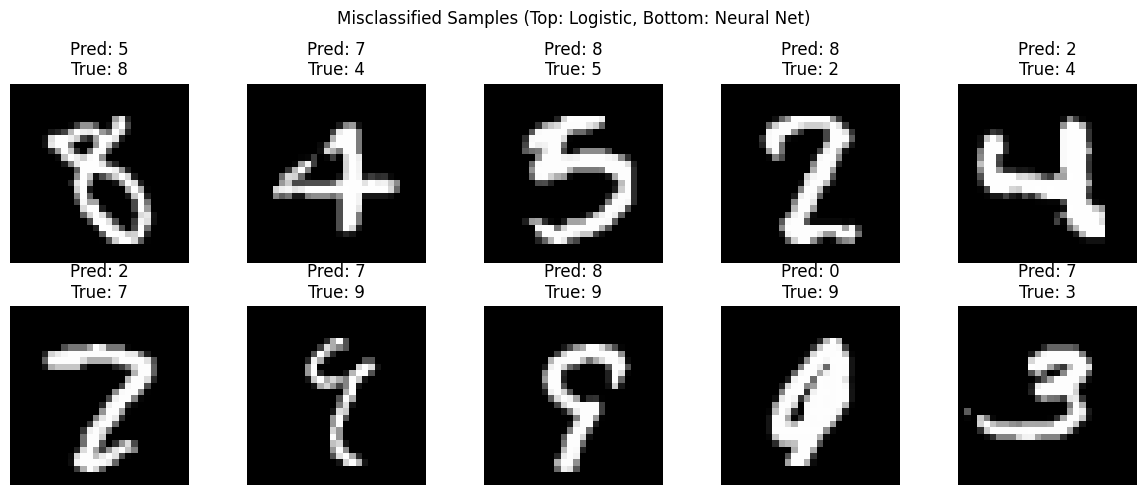

In [10]:
# Provide your code for part 4-3 here
import numpy as np

# Get indices of misclassified examples for both models
misclassified_lr = np.where(lr_preds != y_test)[0]
misclassified_mlp = np.where(mlp_preds != y_test)[0]

# Show first 5 misclassified examples for each model
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
fig.suptitle('Misclassified Samples (Top: Logistic, Bottom: Neural Net)')

for i in range(5):
    # Logistic Regression misclassified
    idx_lr = misclassified_lr[i]
    axes[0, i].imshow(X_test[idx_lr].reshape(28, 28), cmap='gray')
    axes[0, i].set_title(f"Pred: {lr_preds[idx_lr]}\nTrue: {y_test[idx_lr]}")
    axes[0, i].axis('off')

    # Neural Network misclassified
    idx_mlp = misclassified_mlp[i]
    axes[1, i].imshow(X_test[idx_mlp].reshape(28, 28), cmap='gray')
    axes[1, i].set_title(f"Pred: {mlp_preds[idx_mlp]}\nTrue: {y_test[idx_mlp]}")
    axes[1, i].axis('off')

plt.tight_layout()
plt.show()